In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data.loader import fetch_prices
from pairs.selection import find_pairs, compute_spread
from pairs.metrics import fit_ou
from signals.zscore import compute_zscore, generate_signals
from signals.kalman import run_kalman, generate_kalman_signals
from strategy.backtest import run_backtest, BacktestConfig
from analysis.performance import summarize

## Configuration

In [2]:
TICKERS = ['XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB', 'XLRE']
START = '2010-01-01'
END   = '2024-12-31'
P_THRESHOLD = 0.05
INSPECT_PAIR = None  # set to ('TICK1', 'TICK2') to pin a specific pair

# Kalman filter tuning
DELTA = 1e-4   # how fast the hedge ratio can change (higher = faster adaptation)

# Signal thresholds (same for both static and Kalman for fair comparison)
ENTRY_Z = 2.0
EXIT_Z  = 0.0
STOP_Z  = 3.0
COST_BPS = 5.0

## What is the Kalman Filter?

Everything before this notebook used a static hedge ratio. It was estimated once from all the historical data and then held fixed for the entire backtest. That is a strong assumption: it says the relationship between XLB and XLV is the same in 2020 as it was in 2014.

The Kalman filter drops that assumption. It treats the hedge ratio as a hidden quantity that evolves over time, and re-estimates it every day using only data available up to that point.

**The two steps repeated every day:**

**Predict.** Before seeing today's prices, the filter asks: where is the hedge ratio probably today? Its answer: close to where it was yesterday, with a small amount of drift allowed.

**Update.** After seeing today's prices, it computes how wrong the prediction was. This error is called the innovation. The estimate then moves toward the value that would have made the prediction more accurate. How far it moves depends on the Kalman gain, which balances trust in the prior estimate against trust in the new data.

**Why the innovation is the signal.**
The innovation is the part of today's price move that the model did not expect. When the innovation is large and positive, the first stock moved much more than its relationship with the second would predict. Dividing by the expected standard deviation of the innovation produces a z-score-like quantity in standardized units. This is the Kalman z-score and serves as the trading signal; no separate z-score computation is needed.

**The delta parameter.**
Delta controls how fast the hedge ratio is allowed to drift per day. A very small delta (1e-5) produces a nearly static estimate. A larger delta (1e-3) allows rapid shifts. Too small and the filter is slow to detect real changes; too large and it tracks noise.

## 1. Load Data and Select Pair

In [3]:
prices = fetch_prices(TICKERS, START, END)
pairs  = find_pairs(prices, p_threshold=P_THRESHOLD)

if INSPECT_PAIR:
    t1, t2 = INSPECT_PAIR
    match = next((p for p in pairs if set(p['pair']) == {t1, t2}), None)
    static_hedge_ratio = match['hedge_ratio'] if match else 1.0
else:
    best = pairs[0]
    t1, t2 = best['pair']
    static_hedge_ratio = best['hedge_ratio']

print(f"Pair: {t1}/{t2}")
print(f"Static hedge ratio (OLS, fixed): {static_hedge_ratio:.4f}")

Pair: XLP/XLU
Static hedge ratio (OLS, fixed): 2.1292


## 2. Run the Kalman Filter

In [4]:
kf = run_kalman(prices, t1, t2, delta=DELTA)
kf.tail()

,hedge_ratio,intercept,spread,innovation,innovation_std
Date,,,,,
2024-12-23,1.532552,20.171717,20.157254,-0.616612,0.378812
2024-12-24,1.537288,20.170299,20.174449,0.178809,0.380829
2024-12-26,1.547304,20.171884,20.180794,0.382012,0.379900
2024-12-27,1.541915,20.170800,20.165988,-0.205224,0.378852
2024-12-30,1.524281,20.165820,20.149974,-0.670242,0.377324


## 3. How Did the Hedge Ratio Change Over Time?

This chart does not exist in any static approach. The Kalman filter produces a day-by-day estimate of how the relationship between the two stocks evolved. A flat line means the relationship was stable and the static OLS estimate was probably adequate. Drift or sharp moves mean the static ratio was wrong for significant stretches.

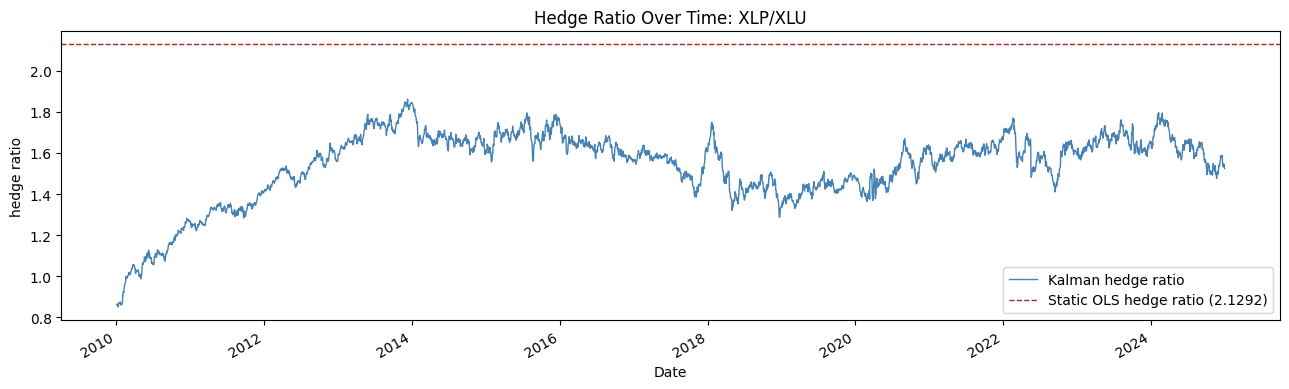

Kalman hedge ratio range: 0.8498 to 1.8624
Static hedge ratio:        2.1292 (fixed)
Total drift: 1.0126


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
kf['hedge_ratio'].plot(ax=ax, color='steelblue', linewidth=1, label='Kalman hedge ratio')
ax.axhline(static_hedge_ratio, color='firebrick', linestyle='--', linewidth=1,
           label=f'Static OLS hedge ratio ({static_hedge_ratio:.4f})')
ax.set_title(f'Hedge Ratio Over Time: {t1}/{t2}')
ax.set_ylabel('hedge ratio')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Kalman hedge ratio range: {kf['hedge_ratio'].min():.4f} to {kf['hedge_ratio'].max():.4f}")
print(f"Static hedge ratio:        {static_hedge_ratio:.4f} (fixed)")
print(f"Total drift: {kf['hedge_ratio'].max() - kf['hedge_ratio'].min():.4f}")

> **Observations: Hedge Ratio Drift**
>
> The Kalman hedge ratio drifted substantially. It ranged from 0.85 to 1.86 over the full period, a total drift of 1.01, roughly half the static OLS ratio of 2.13. The two never agree: the Kalman estimate is systematically lower than the static OLS throughout the entire history. This is not noise; it is a persistent disagreement between the two estimation methods.
>
> The drift means the Kalman filter believes the relationship between XLP and XLU changed significantly over time. Whether that belief is correct determines whether the Kalman spread or the static spread is better-behaved. The comparison in section 5 will settle this, but a drift this large (47% of the static ratio) is a warning sign that the Kalman may be chasing noise rather than tracking a real structural shift.

## 4. Kalman Z-Score vs Static Z-Score

The Kalman z-score (innovation divided by its expected standard deviation) should look different from the static z-score because the reference model is updating every day instead of using a fixed historical mean. When the two diverge significantly, the static approach was measuring deviations from a stale reference point.

Window: 60 days
Static spread std:  2.5970
Kalman spread std:  4.077584


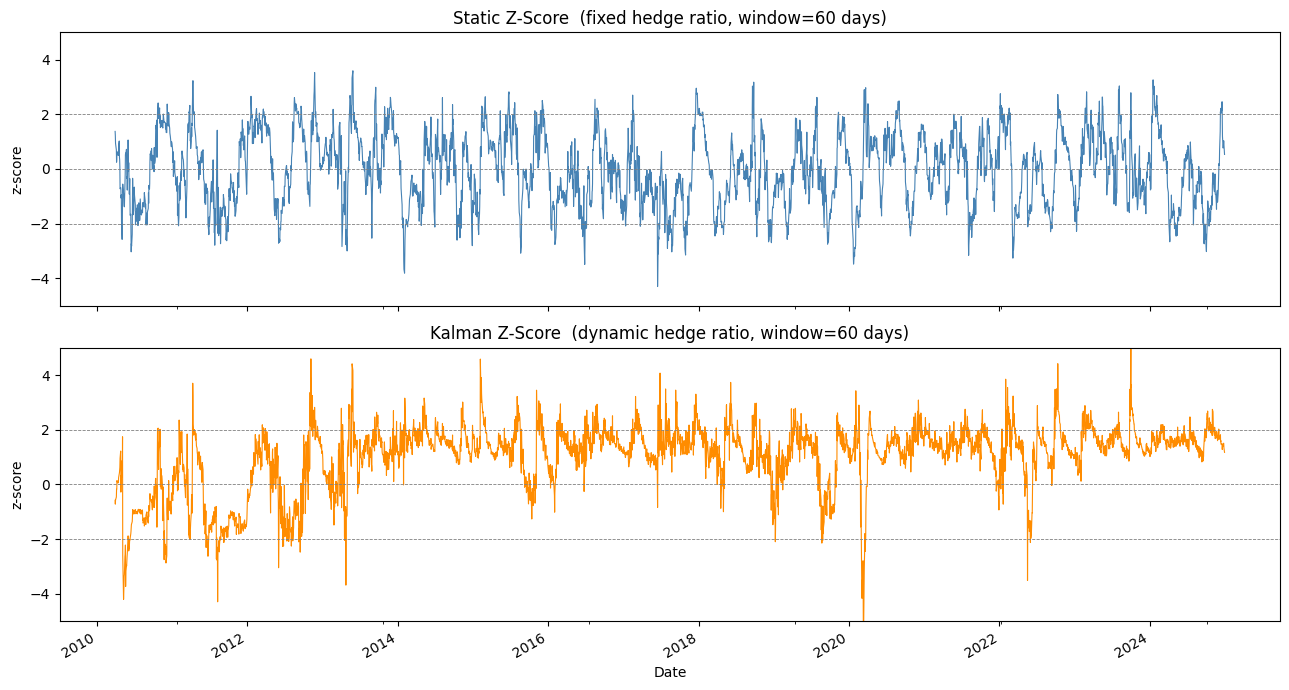

In [6]:
# Static z-score using half-life window
spread_static = compute_spread(prices, t1, t2, static_hedge_ratio)
ou_static = fit_ou(spread_static)
static_window = int(round(ou_static['half_life'])) if ou_static['is_valid'] else 30
zscore_static = compute_zscore(spread_static, window=static_window)

# Kalman z-score: use the same window as the static approach.
# The Kalman spread is much tighter (dynamic hedge ratio absorbs most variation),
# so fitting OU on it directly gives a degenerate result. The static window
# is the right reference period for both signals.
kalman_window = static_window
zscore_kalman = compute_zscore(kf['spread'], window=kalman_window)

print(f"Window: {static_window} days")
print(f"Static spread std:  {spread_static.std():.4f}")
print(f"Kalman spread std:  {kf['spread'].std():.6f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

zscore_static.plot(ax=axes[0], color='steelblue', linewidth=0.8)
for level in [-ENTRY_Z, 0, ENTRY_Z]:
    axes[0].axhline(level, color='grey', linestyle='--', linewidth=0.6)
axes[0].set_title(f'Static Z-Score  (fixed hedge ratio, window={static_window} days)')
axes[0].set_ylabel('z-score')
axes[0].set_ylim(-5, 5)

zscore_kalman.plot(ax=axes[1], color='darkorange', linewidth=0.8)
for level in [-ENTRY_Z, 0, ENTRY_Z]:
    axes[1].axhline(level, color='grey', linestyle='--', linewidth=0.6)
axes[1].set_title(f'Kalman Z-Score  (dynamic hedge ratio, window={kalman_window} days)')
axes[1].set_ylabel('z-score')
axes[1].set_ylim(-5, 5)

plt.tight_layout()
plt.show()

> **Observations: Z-Score Comparison**
>
> The two z-scores tell very different stories. The Kalman spread standard deviation is 4.08 versus 2.60 for the static spread; the Kalman z-score is about 57% more volatile. This pushes the Kalman signal into extreme territory more often: it spends 80.5% of the time in a trade (3,037/3,773 days) versus only 53.9% for the static approach.
>
> More time in market is not inherently better. It depends on whether those extra trades make money. Given that the Kalman hedge ratio is systematically lower than the static OLS, the Kalman spread is not the true cointegrating combination. The elevated volatility in the Kalman z-score is likely reflecting a misspecified spread rather than genuine trading opportunities.

## 5. Backtest: Kalman Strategy

The Kalman backtest uses the time-varying hedge ratio from the filter output. Each day's PnL is computed with that day's estimate, shifted one day forward to avoid lookahead bias.

In [7]:
signals_kalman = generate_kalman_signals(kf, window=kalman_window, entry=ENTRY_Z, exit=EXIT_Z, stop=STOP_Z)

config_kalman = BacktestConfig(t1=t1, t2=t2, hedge_ratio=kf['hedge_ratio'], cost_bps=COST_BPS)
results_kalman = run_backtest(prices, signals_kalman, config=config_kalman)

print(f"Kalman - Days in market: {(signals_kalman != 0).sum()} / {len(signals_kalman)}  "
      f"({100*(signals_kalman != 0).mean():.1f}%)")

Kalman - Days in market: 3037 / 3773  (80.5%)


## 6. Backtest - Static Strategy (for comparison)

In [8]:
signals_static = generate_signals(zscore_static, entry=ENTRY_Z, exit=EXIT_Z, stop=STOP_Z)
config_static  = BacktestConfig(t1=t1, t2=t2, hedge_ratio=static_hedge_ratio, cost_bps=COST_BPS)
results_static = run_backtest(prices, signals_static, config=config_static)

print(f"Static - Days in market: {(signals_static != 0).sum()} / {len(signals_static)}  "
      f"({100*(signals_static != 0).mean():.1f}%)")

Static - Days in market: 2033 / 3773  (53.9%)


## 7. Side-by-Side Performance Comparison

In [9]:
stats_static = summarize(results_static)
stats_kalman = summarize(results_kalman)

print(f"{'Metric':<22} {'Static':>12} {'Kalman':>12}")
print("-" * 48)
for k in stats_static:
    print(f"{k:<22} {str(stats_static[k]):>12} {str(stats_kalman[k]):>12}")

Metric                       Static       Kalman


------------------------------------------------
total_return                 0.8219      -0.1448
annualized_return            0.0549      -0.0097
sharpe_ratio                  0.593       -0.108
max_drawdown                -0.2035        -0.34
num_trades                      171          125
win_rate                      0.628        0.397
avg_trade_pnl              0.010051    -0.001806


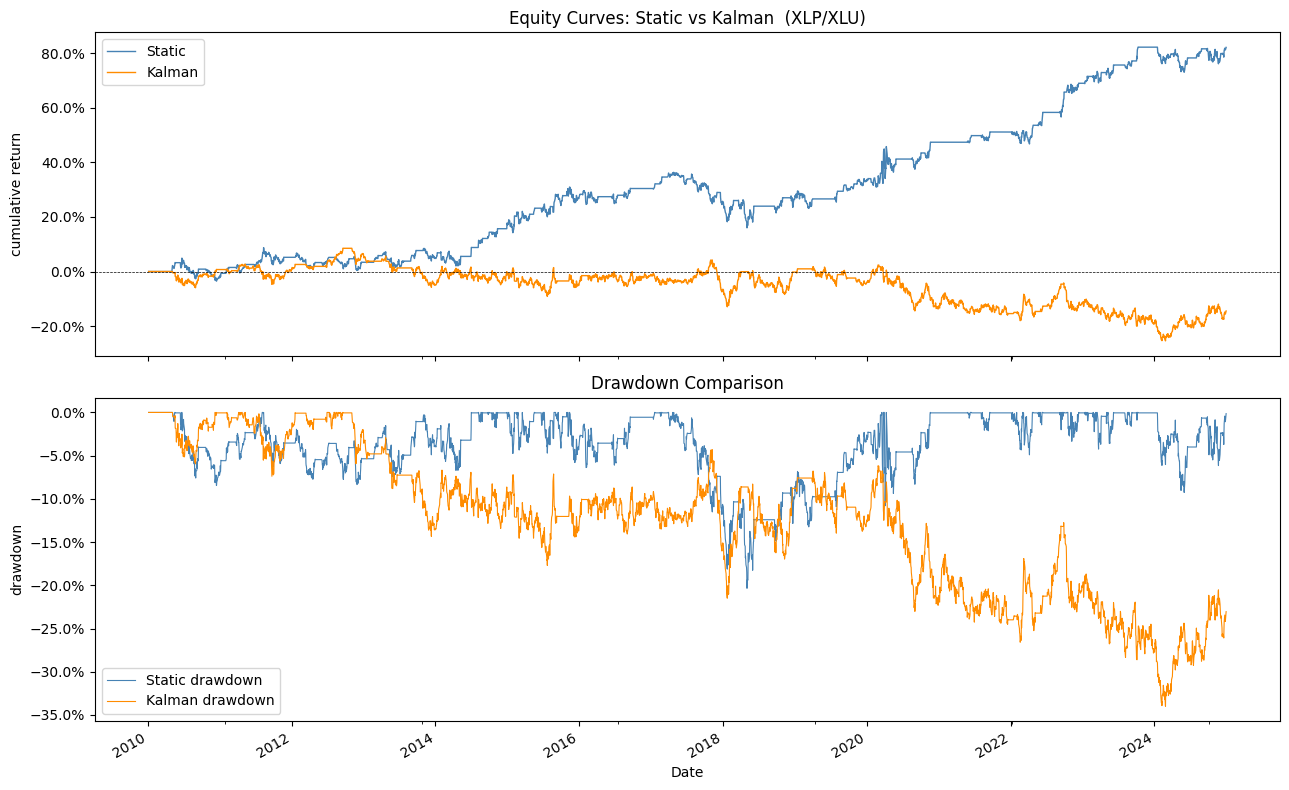

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Equity curves
results_static['equity'].plot(ax=axes[0], color='steelblue', linewidth=1, label='Static')
results_kalman['equity'].plot(ax=axes[0], color='darkorange', linewidth=1, label='Kalman')
axes[0].axhline(0, color='k', linewidth=0.5, linestyle='--')
axes[0].set_title(f'Equity Curves: Static vs Kalman  ({t1}/{t2})')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend()

# Drawdowns
dd_static = results_static['equity'] - results_static['equity'].cummax()
dd_kalman = results_kalman['equity'] - results_kalman['equity'].cummax()
dd_static.plot(ax=axes[1], color='steelblue', linewidth=0.8, label='Static drawdown')
dd_kalman.plot(ax=axes[1], color='darkorange', linewidth=0.8, label='Kalman drawdown')
axes[1].set_title('Drawdown Comparison')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1].legend()

plt.tight_layout()
plt.show()

> **Observations: Static vs Kalman**
>
> The Kalman filter made things dramatically worse. Static OLS: Sharpe 0.59, total return 82.2%, max drawdown -20.4%, win rate 62.8%. Kalman: Sharpe -0.11, total return -14.5%, max drawdown -34.0%, win rate 39.7%. Every metric deteriorated.
>
> The root cause is the hedge ratio divergence from section 3. The Kalman filter estimated a hedge ratio around 0.85 to 1.86 while the true cointegrating ratio (OLS) is 2.13. Trading against a misspecified spread means the Kalman strategy is betting on a relationship that does not exist in the data. The spread constructed with the Kalman ratio is not mean-reverting, so trades systematically lose.
>
> This is a strong argument for the static OLS approach: when the pair is genuinely cointegrated (p=0.0007), the long-run relationship is stable and the simple fixed hedge ratio captures it better than an adaptive filter that can drift to the wrong value.